# Etapa: Avance 1. Análisis exploratorio de datos

**Proyecto Integrador — Equipo 53**

| Integrante | Matrícula |
|---|---|
| Fernando Moreira Guerra | A00618568 |
| Daniel Molina León | A01796535 |
| Pedro Cuauhtémoc Márquez Correo | A01796847 |

**Profesor / Sponsor:** Gerardo Jesús Camacho González, PhD.

---

**Contenido**

1. Introducción
2. Fuentes de datos usadas para el proyecto
3. Modelo eléctrico y naturaleza de las gráficas
4. Condiciones que causan múltiples máximos locales
5. Análisis comparativo P-Iref vs P-Vref
6. Estructura de los datos
7. Análisis univariante
8. Análisis bi/multivariante
9. Preprocesamiento
10. Conclusiones del EDA
11. Referencias bibliográficas

> La libreta se ejecuta de principio a fin de forma secuencial. Los archivos de datos deben estar en la carpeta `data/`. Las figuras y los datos limpios se guardan en `outputs/`.

## 1. Introducción

La búsqueda de soluciones energéticas sostenibles ha impulsado significativamente el desarrollo de sistemas fotovoltaicos, consolidados como un pilar clave en la transformación del panorama energético global. Estos sistemas convierten la radiación solar en electricidad, pero su eficiencia depende críticamente de operar en el punto de máxima potencia (MPP), donde se extrae la máxima energía disponible. Este objetivo es esencial para maximizar la rentabilidad y estabilidad de las instalaciones fotovoltaicas.

Bajo condiciones de sombreado parcial (PSC), causado por obstrucciones como nubes, árboles o estructuras, la característica corriente-voltaje (I-V) del panel presenta un comportamiento radicalmente diferente al de irradiancia uniforme. En lugar de un único máximo global (GMPP), la curva potencia-voltaje (P-V) desarrolla múltiples máximos locales, complicando significativamente la identificación del punto de máxima potencia global. Este comportamiento multimodal es la barrera fundamental que hace que los algoritmos tradicionales de seguimiento del punto de máxima potencia (MPPT), como Perturbación y Observación (P&O) e Incremento de Conductancia (INC), fallen en localizar el GMPP, resultando en pérdidas de energía aprovechable.

El presente reporte se enfoca en el análisis de los datos descritos en la Fase 0 (Entendimiento del Negocio y de los Datos) del ciclo CRISP-ML(Q) del proyecto y que han sido proporcionados por el patrocinador del proyecto.

## 2. Fuentes de datos usadas para el proyecto

El proyecto utiliza dos fuentes de datos complementarias que se integran en el marco de CRISP-ML(Q) para proporcionar conjuntos de entrenamiento, validación y prueba:

### Datos de referencia del paper base

El proyecto cuenta con cuatro conjuntos de datos (formato .csv) que contienen las curvas corriente–voltaje–potencia (I-V-P) de un panel fotovoltaico Renesola JC250 bajo cuatro condiciones de irradiancia: una uniforme (Caso 1, que funciona como control) y tres de sombreado parcial (Casos 2 a 4). Estos datos fueron generados por simulación numérica del modelo de un diodo del panel, con las irradiancias reportadas en el documento base, a 25 °C.

Entre sus características principales podemos encontrar que representan la respuesta simulada de un panel comercial con los parámetros del fabricante (Tabla 1 del paper base) e incluyen la curva característica completa I-V, a partir de la cual se derivan P-V y P-I.

### Datos sintéticos generados por simulación

Dado que cuatro escenarios fijos son insuficientes para entrenar un agente que generalice a patrones de sombreado desconocidos, se generarán programáticamente patrones de sombreado adicionales mediante un modelo eléctrico de panel fotovoltaico de nivel celda. Para este caso las características principales que podemos identificar son:

- Utilizará un modelo de diodo por segmento del panel con diodos de bypass integrados.
- Permitirá producir un número prácticamente ilimitado de curvas P-V con características realistas.
- Generará patrones de sombreado aleatorios que cubran un amplio espacio de variabilidad.

## 3. Modelo eléctrico y naturaleza de las gráficas

### 3.1 Modelo eléctrico simplificado del panel fotovoltaico

Un panel fotovoltaico está compuesto por celdas solares conectadas en serie y en paralelo. Para fines de simulación y análisis, se utiliza el modelo de un diodo simplificado que captura los comportamientos esenciales de una celda solar:

$$I = I_{ph} - I_0\left[\exp\left(\frac{qV}{nkT}\right) - 1\right] - \frac{V}{R_{sh}}$$

Donde:

- $I$ = corriente de la celda (A)
- $I_{ph}$ = fotocorriente, dependiente de irradiancia (A)
- $I_0$ = corriente de saturación inversa del diodo, dependiente de temperatura (A)
- $V$ = voltaje en la celda (V)
- $q$ = carga del electrón (1.602 × 10⁻¹⁹ C)
- $n$ = factor de idealidad del diodo (1-2)
- $k$ = constante de Boltzmann (1.381 × 10⁻²³ J/K)
- $T$ = temperatura absoluta (K)
- $R_{sh}$ = resistencia shunt (Ω)

Para un panel completo compuesto por $N_s$ celdas en serie y $N_p$ ramas en paralelo, la ecuación se extiende considerando que:

- Voltaje total del panel = $N_s$ × V_celda
- Corriente total del panel = $N_p$ × I_rama

Con la incorporación de diodos de bypass (típicamente uno por tercio del panel), la configuración permite que celdas sombreadas se corten (bypass) mediante estos diodos cuando su voltaje directo excede un umbral, evitando que actúen como carga resistiva. Esto introduce discontinuidades en la característica I-V que resultan en múltiples máximos en la curva P-V, la firma característica del sombreado parcial.

### 3.2 Proceso de generación de datos sintéticos

El simulador genera datos sintéticos siguiendo este proceso:

1. **Especificación del patrón de sombreado:** Se define la irradiancia para cada segmento del panel (por ejemplo, irradiancia uniforme de 1000 W/m² para celdas libres, reducida, por ejemplo, a valores entre 175 y 652 W/m², como en los casos del paper base).
2. **Evaluación de la característica I-V:** Se resuelve iterativamente la ecuación de diodo modificada para cada voltaje en el rango [0, Voc], obteniendo la corriente correspondiente a ese voltaje bajo el patrón de sombreado especificado.
3. **Cálculo de potencia:** P(V) = V × I(V), generando la característica P-V completa.
4. **Identificación del GMPP:** Se localiza el máximo global en la curva P-V y se registra el voltaje y corriente correspondientes.

### 3.3 Tipos de gráficas generadas

El análisis de datos genera varios tipos de gráficas, cada una con un propósito específico en el entendimiento del comportamiento del sistema:

**Curva I-V Característica (Corriente vs. Voltaje):** Muestra la relación fundamental entre corriente y voltaje del panel bajo una condición específica de sombreado. La forma de esta curva (normalmente descendente) refleja cómo la disponibilidad de corriente disminuye conforme aumenta el voltaje. Bajo sombreado parcial, la curva I-V puede presentar "escalones" causados por la activación secuencial de diodos de bypass, un fenómeno clave para entender la generación de múltiples máximos en potencia.

**Curva P-V Característica (Potencia vs. Voltaje):** Se obtiene multiplicando I(V) por V. Bajo irradiancia uniforme, esta curva presenta un único máximo bien definido. Bajo sombreado parcial, desarrolla múltiples máximos locales separados por valles, siendo el pico más alto el GMPP y el objetivo del algoritmo MSAPSO. El análisis de esta curva es central para validar que los datos sintéticos reproducen el comportamiento real.

**Curva P-I Característica (Potencia vs. Corriente):** Muestra la relación P(I) = I × V(I), donde V(I) se obtiene invirtiendo la relación I-V. Esta representación es fundamental para el algoritmo MSAPSO cuando opera con referencias de corriente (P-Iref), ya que permite evaluar la potencia alcanzable para cada corriente candidata. La forma de P-I difiere significativamente de P-V, con implicaciones importantes para la velocidad y estabilidad de convergencia. En la sección 8.3 se comparan ambas curvas con los datos.

## 4. Condiciones que causan múltiples máximos locales

### 4.1 Mecanismo físico

El fenómeno de múltiples máximos bajo sombreado parcial resulta de una interacción física fundamental: cuando una celda está sombreada, su fotocorriente (Iph) se reduce proporcionalmente a la disminución de irradiancia. En un string (serie de celdas), todas las celdas deben conducir la misma corriente debido a la conexión en serie. Por tanto, una celda sombreada con Iph reducida actúa como un "cuello de botella" o limitador de corriente para todo el string, restringiendo la corriente máxima que puede fluir.

Bajo esta restricción de corriente, las celdas no sombreadas en el mismo string pueden operar a múltiples voltajes sin violar la restricción de corriente. Esto genera múltiples "regiones de operación viable" para el panel completo, cada una con un nivel de potencia diferente.

### 4.2 Rol de diodos de bypass

Un panel típicamente incluye diodos de bypass (usualmente uno cada 10-20 celdas) que permiten que un grupo de celdas sea "cortocircuitado" cuando su voltaje conjunto alcanza un umbral. Cuando un bloque de celdas está suficientemente sombreado, el diodo de bypass asociado se activa, permitiendo que la corriente fluya alrededor de ese bloque en lugar de a través de él.

Esta característica introduce discontinuidades en la curva I-V: conforme aumenta el voltaje total del panel, diferentes diodos de bypass se activan secuencialmente, causando cambios abruptos en la corriente disponible. En la curva P-V resultante, estos cambios se traducen en múltiples máximos locales, cada uno correspondiente a una "configuración de bypass" diferente (qué diodos están activos y cuáles no).

### 4.3 Configuraciones no conectadas

Un aspecto crítico es que las celdas libres (no sombreadas) en diferentes strings (ramas en paralelo) pueden operar de manera independiente. En arreglos con ramas en paralelo (no es el caso del panel JC250, de 60 celdas en serie), por ejemplo:

- String 1: Completamente libre, Isc(1) = 10 A
- String 2: 50% sombreado, Isc(2) = 5 A

El voltaje total del panel está limitado por el voltaje máximo que ambos strings pueden alcanzar en paralelo. Sin embargo, los strings pueden alcanzar máxima potencia a voltajes diferentes. El panel resultante presentará múltiples máximos que representan diferentes máximos entre los puntos óptimos de cada string — estos máximos corresponden a puntos donde "uno de los strings está en su óptimo local mientras el otro está operando a un punto subóptimo."

En nuestro panel, el efecto equivalente ocurre entre sub-bloques en serie con distinta irradiancia, separados por diodos de bypass, que no necesariamente están contiguos físicamente.

### 4.4 Ejemplos de patrones de sombreados

**Patrón 1: Sombreado Uniforme en Checkerboard (Ajedrez):** Celdas alternadas están sombreadas uniformemente. Generalmente produce dos o tres máximos principales bien separados en voltaje, cada uno correspondiendo a diferentes configuraciones de bypass. Los máximos tienden a ser de amplitud comparable, haciendo que algoritmos sin búsqueda global tengan dificultad para distinguir cuál es el verdadero GMPP.

**Patrón 2: Sombreado Localizado (Bloque Continuo):** Un tercio del panel está sombreado como un bloque contiguo. Produce un máximo principal a voltaje alto (donde el bloque sombreado es bypasseado) y máximos secundarios a voltajes más bajos. El GMPP está claramente en el voltaje más alto, pero las técnicas perturbativas pueden quedar atrapadas en máximos locales secundarios a voltajes bajos.

**Patrón 3: Sombreado Distribuido en Múltiples Ubicaciones:** Bloques de sombreado en diferentes strings. Produce una curva P-V con múltiples máximos de amplitudes variadas, sin una estructura regular. Este patrón es particularmente desafiante porque no tiene simetría que algoritmos simples puedan explotar.

### 4.5 Los cuatro casos del proyecto

Los cuatro casos corresponden a las condiciones de irradiancia del paper base, a 25 °C. El número de picos y el GMPP se obtuvieron de los archivos de datos (sección 8):

| Caso | Irradiancias (W/m²) | Tipo | Picos en P-V | GMPP |
|---|---|---|---|---|
| 1 | 800 / 800 | Uniforme | 1 | 201.0 W |
| 2 | 1000 / 652 | Sombreado parcial | 2 | 176.3 W |
| 3 | 365 / 175 | Sombreado parcial | 2 | 46.7 W |
| 4 | 175 / 1000 / 607 / 365 | Sombreado parcial | 4 | 75.2 W |

En general, a más niveles de irradiancia distintos, más picos aparecen en la curva P-V. El Caso 1 sirve como referencia sin sombreado. El Caso 4 es el más complejo: sus dos picos más altos tienen casi la misma potencia, lo que hace más difícil identificar cuál es el GMPP.

## 5. Análisis comparativo P-Iref vs P-Vref

### 5.1 Definiciones

El algoritmo MSAPSO opera generando referencias de control para el panel fotovoltaico. Estas referencias pueden ser de dos tipos:

**P-Vref (Control de Voltaje):** El algoritmo genera una secuencia de referencias de voltaje Vref ∈ [0, Voc]. El controlador super-twisting mantiene el panel operando a V = Vref, y se mide la potencia resultante P = V × I(V).

**P-Iref (Control de Corriente):** El algoritmo genera una secuencia de referencias de corriente Iref ∈ [0, Isc]. El controlador super-twisting mantiene el panel operando a I = Iref, y se mide la potencia resultante P = I × V(I).

### 5.2 Diferencias en la topología de búsqueda

Aunque ambas estrategias buscan explorar un espacio unidimensional, los límites y características del espacio difieren:

**Espacio de Voltaje [0, Voc]:** Voc (voltaje de circuito abierto) es el voltaje del panel a corriente nula. Bajo sombreado parcial, Voc disminuye pero permanece en un rango relativamente estable (~0.6 V por celda; en los datos, entre 35.0 y 37.0 V para las 60 celdas). El espacio de búsqueda es bien acotado pero no se adapta de manera intuitiva a cambios en irradiancia.

**Espacio de Corriente [0, Isc]:** Isc (corriente de cortocircuito) es la corriente máxima disponible, directamente proporcional a la irradiancia total. Bajo sombreado parcial, Isc disminuye proporcionalmente, reduciendo automáticamente el espacio de búsqueda. Esto es deseable porque el algoritmo "naturalmente" reduce su rango de búsqueda cuando menos energía está disponible, sin requerir ajustes manuales de parámetros.

### 5.3 Suavidad de la topología fitness

Una diferencia crucial emerge en cómo el "paisaje" de potencia varía conforme se cambian las referencias:

**Característica P-V (Control de Voltaje):** La curva P-V es característicamente abrupta bajo sombreado. Los máximos locales son muy pronunciados (picos agudos) con caídas rápidas hacia los valles. Esta topología "accidentada" hace que perturbaciones pequeñas en voltaje generen variaciones grandes en potencia, dificultando que un algoritmo heurístico distinga mejoras graduales. El paisaje es altamente multimodal con regiones de "enganche" donde el algoritmo puede quedar atrapado.

**Característica P-I (Control de Corriente):** La curva P-I es más suave debido a que cambios en corriente producen variaciones más graduales en voltaje (a través de la característica I-V invertida). Los máximos siguen siendo pronunciados, pero las transiciones entre ellos son menos abruptas. El paisaje presenta "laderas" más suaves alrededor de cada máximo, permitiendo que el algoritmo navegue de manera más coherente entre regiones. Esta suavidad relativa reduce la tendencia del algoritmo de "saltar" entre máximos sin control.

### 5.4 Implicaciones para convergencia y estabilidad

Estas diferencias en topología tienen consecuencias directas para el desempeño del algoritmo:

**Control P-Vref:** El algoritmo percibe cambios erráticos en fitness conforme se perturba el voltaje, resultando en tiempos de convergencia variables y predecibles. El controlador super-twisting debe ser rápido para seguir referencias que cambian significativamente entre iteraciones, introduciendo dinámicas transitorias más severas. Las oscilaciones alrededor del GMPP tienden a ser mayores.

**Control P-Iref:** El algoritmo percibe cambios más graduales en fitness, permitiendo que desarrolle una comprensión más coherente del paisaje de soluciones. La convergencia es más determinista y predecible. El controlador super-twisting trabaja con una variable (corriente) que es más directamente controlable mediante el ciclo de trabajo del convertidor, resultando en dinámicas más rápidas y con menos overshoot. Las oscilaciones son menores.

Considerando todo lo anterior, P-Iref presenta varias ventajas técnicas sobre P-Vref:

- Presenta una topología de búsqueda más suave por lo que facilita la convergencia más rápida y determinista para el algoritmo de MSAPSO.
- El espacio de búsqueda se adapta automáticamente a la irradiancia sin requerir recalibración de parámetros.
- La corriente es una variable más rápida de controlar con lo que se reducen transitorios y oscilaciones del controlador.
- Tener menos oscilaciones implica tener menos energía desperdiciada durante la búsqueda GMPP.
- El control de corriente es más robusto a variaciones en la carga de salida.

## 6. Estructura de los datos

### 6.1 Carga de los datos

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")        # carpeta con los archivos Caso*.csv
OUT_DIR = Path("outputs")      # carpeta donde se guardan figuras y datos limpios
OUT_DIR.mkdir(exist_ok=True)

CASOS = [1, 2, 3, 4]
VARS = ["corriente", "voltaje", "potencia"]
COLORES = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a", 4: "#eda100"}

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "font.size": 9})

# Se cargan los cuatro casos y se agrega una columna 'caso' para identificarlos
datos = {}
for i in CASOS:
    df = pd.read_csv(DATA_DIR / f"Caso{i}.csv")
    df["caso"] = i
    datos[i] = df

df_all = pd.concat(datos.values(), ignore_index=True)
df_all["caso"] = df_all["caso"].astype("category")

print("Forma del conjunto:", df_all.shape)
display(df_all.head())

Forma del conjunto: (1392, 4)


,corriente,voltaje,potencia,caso
0,7.122869,0.000000e+00,0.000000e+00,1
1,7.122869,2.950340e-29,2.101488e-28,1
2,7.119702,6.599133e-05,4.698386e-04,1
3,7.118164,1.319827e-04,9.394742e-04,1
4,7.117416,1.979740e-04,1.409063e-03,1


### 6.2 Archivos `caso_*.csv`

Además de `Caso*.csv`, se recibieron los archivos `caso_*.csv`. Revisamos si contienen la misma información.

In [2]:
for i in CASOS:
    original = datos[i][VARS].values
    otro = pd.read_csv(DATA_DIR / f"caso_{i}.csv", header=None).values
    iguales = np.allclose(original, otro, rtol=0, atol=1e-9)
    print(f"Caso {i}: filas {len(original)} vs {len(otro)} | mismos valores: {iguales}")

Caso 1: filas 319 vs 319 | mismos valores: True
Caso 2: filas 440 vs 440 | mismos valores: True
Caso 3: filas 216 vs 216 | mismos valores: True
Caso 4: filas 417 vs 417 | mismos valores: True


Los archivos `caso_*.csv` tienen los mismos datos que `Caso*.csv`, pero sin encabezado. Por eso trabajamos solo con `Caso*.csv`.

### 6.3 Tipos de datos, valores faltantes y duplicados

In [3]:
df_all.info()
print("\nValores faltantes por columna:")
print(df_all.isna().sum())
print("\nFilas duplicadas:", df_all[VARS + ["caso"]].duplicated().sum())

# La potencia se calcula como voltaje x corriente: verificamos que se cumpla
error = (df_all["potencia"] - df_all["voltaje"] * df_all["corriente"]).abs().max()
print(f"\nDiferencia máxima entre potencia y voltaje*corriente: {error:.1e} W")

<class 'pandas.DataFrame'>
RangeIndex: 1392 entries, 0 to 1391
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   corriente  1392 non-null   float64 
 1   voltaje    1392 non-null   float64 
 2   potencia   1392 non-null   float64 
 3   caso       1392 non-null   category
dtypes: category(1), float64(3)
memory usage: 34.1 KB

Valores faltantes por columna:
corriente    0
voltaje      0
potencia     0
caso         0
dtype: int64

Filas duplicadas: 0

Diferencia máxima entre potencia y voltaje*corriente: 8.5e-13 W


El conjunto tiene 1,392 filas, tres variables numéricas (corriente, voltaje y potencia) y la variable categórica `caso`. No hay valores faltantes ni filas duplicadas, lo cual es esperable porque los datos vienen de una simulación.

La potencia es exactamente voltaje × corriente, es decir, es una variable calculada a partir de las otras dos.

### 6.4 Estadísticas descriptivas por caso

In [4]:
display(df_all.groupby("caso", observed=True)[VARS].describe().T.round(2))

caso                  1       2       3       4
corriente count  319.00  440.00  216.00  417.00
          mean     5.38    5.29    1.70    2.58
          std      1.97    1.79    0.98    2.16
          min      0.03    0.30    0.05    0.02
          25%      4.48    4.17    1.23    1.41
          50%      6.17    5.47    1.54    1.54
          75%      6.75    5.80    2.70    3.22
          max      7.12    8.90    3.25    8.90
voltaje   count  319.00  440.00  216.00  417.00
          mean    29.05   26.98   23.44   26.57
          std      8.96   10.46   11.72   10.53
          min      0.00    0.00    0.00    0.00
          25%     29.75   16.36   14.51   22.65
          50%     31.70   32.07   29.93   32.68
          75%     33.99   34.17   33.00   34.15
          max     37.01   36.88   35.05   36.03
potencia  count  319.00  440.00  216.00  417.00
          mean   146.74  127.02   29.47   46.78
          std     66.50   49.77   15.66   16.73
          min      0.00    0.00    0.00    0.00
          25%     97.53   90.18   15.04   40.07
          50%    187.56  142.33   32.44   49.64
          75%    197.68  170.71   45.11   50.62
          max    201.03  176.27   46.75   75.19

Los casos tienen escalas muy distintas: la potencia máxima va de 46.7 W (Caso 3, irradiancia baja) a 201.0 W (Caso 1). La corriente máxima (corriente de cortocircuito) depende de la irradiancia: 7.12 A en el Caso 1 (800 W/m²), 3.25 A en el Caso 3 y 8.90 A en los Casos 2 y 4, que tienen una parte del panel a 1000 W/m². El voltaje máximo es parecido en los cuatro casos (35 a 37 V).

### 6.5 Variable categórica `caso`

caso
1    319
2    440
3    216
4    417
Name: count, dtype: int64


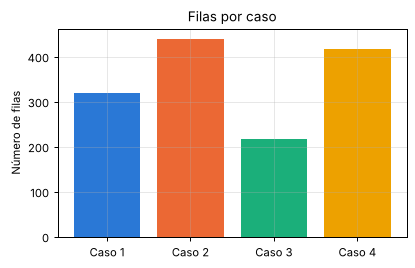

In [5]:
conteo = df_all["caso"].value_counts().sort_index()
print(conteo)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([f"Caso {i}" for i in conteo.index], conteo.values, color=[COLORES[i] for i in conteo.index])
ax.set_ylabel("Número de filas")
ax.set_title("Filas por caso")
fig.savefig(OUT_DIR / "filas_por_caso.png", dpi=120, bbox_inches="tight")
plt.show()

La variable `caso` tiene 4 categorías (baja cardinalidad). El número de filas cambia entre casos (de 216 a 440), pero esto no es un desbalance de clases: cada caso es una sola curva y el número de filas solo indica cuántos puntos usó el simulador para dibujarla.

## 7. Análisis univariante

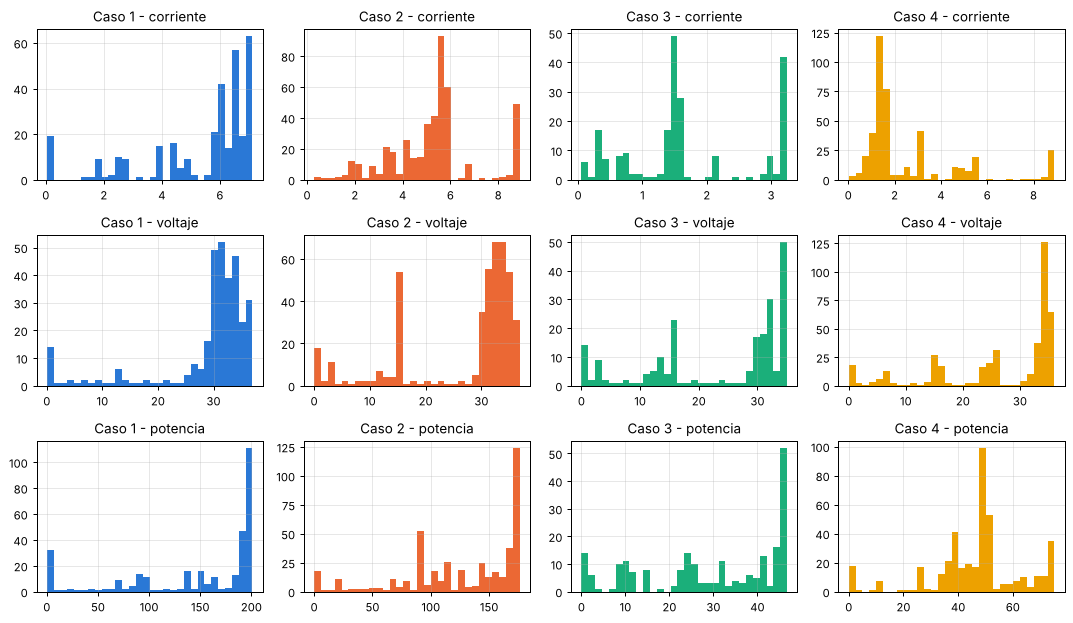

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(12, 7))
for c, i in enumerate(CASOS):
    for r, v in enumerate(VARS):
        axes[r, c].hist(datos[i][v], bins=30, color=COLORES[i])
        axes[r, c].set_title(f"Caso {i} - {v}")
fig.tight_layout()
fig.savefig(OUT_DIR / "histogramas.png", dpi=120, bbox_inches="tight")
plt.show()

,Caso 1,Caso 2,Caso 3,Caso 4
corriente,19,62,0,32
voltaje,43,0,0,27
potencia,0,0,0,90


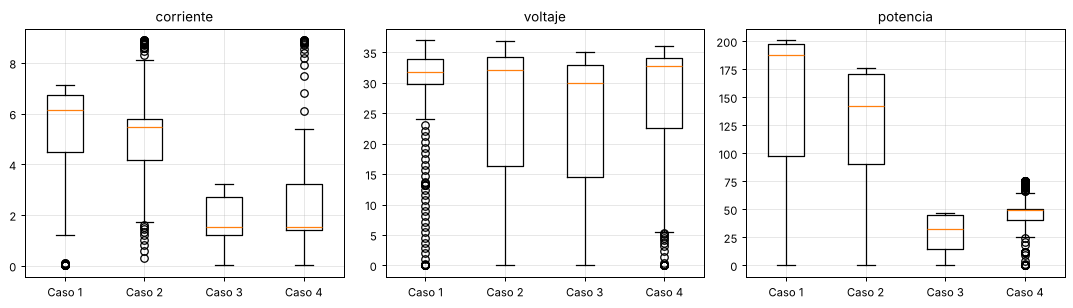

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, v in zip(axes, VARS):
    ax.boxplot([datos[i][v] for i in CASOS])
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels([f"Caso {i}" for i in CASOS])
    ax.set_title(v)
fig.tight_layout()
fig.savefig(OUT_DIR / "boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

# Conteo de atípicos con la regla del rango intercuartílico (1.5 * IQR)
def contar_atipicos(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

display(pd.DataFrame({f"Caso {i}": [contar_atipicos(datos[i][v]) for v in VARS] for i in CASOS}, index=VARS))

Las distribuciones no son normales y varias están sesgadas, por ejemplo el voltaje del Caso 1, donde la mayoría de los puntos están entre 30 y 37 V. Esto pasa porque cada archivo es una curva y no una muestra aleatoria: el simulador no reparte los puntos de manera uniforme, sino que pone más puntos donde la curva cambia rápido. Por eso no consideramos necesario aplicar transformaciones (logaritmo, Box-Cox).

La regla del rango intercuartílico marca algunos puntos como atípicos, pero corresponden a los extremos de la curva (corriente de cortocircuito y voltaje de circuito abierto) o a los escalones causados por el sombreado. Son valores físicamente válidos.

Los datos no tienen una dimensión de tiempo: las filas están ordenadas por voltaje creciente.

## 8. Análisis bi/multivariante

### 8.1 Curvas I-V, P-V y P-I

,corriente,voltaje,potencia
Caso 1,6.69,30.06,201.03
Caso 2,5.59,31.53,176.27
Caso 3,1.51,30.95,46.75
Caso 4,3.16,23.77,75.19


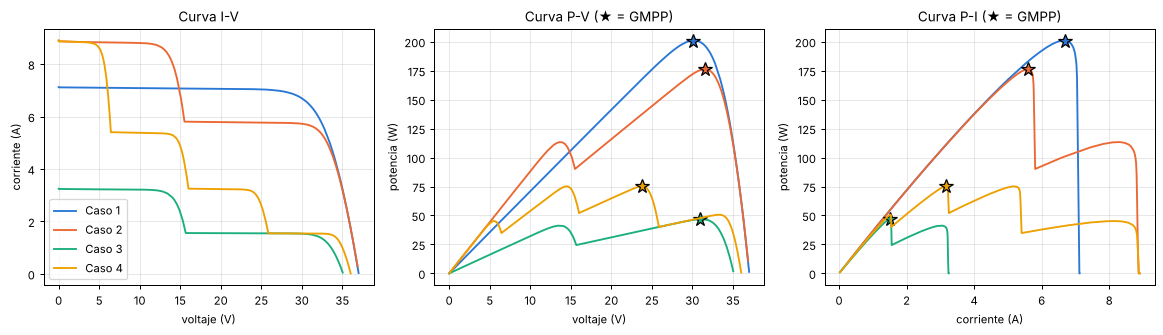

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for i, d in datos.items():
    gmpp = d["potencia"].idxmax()
    axes[0].plot(d["voltaje"], d["corriente"], color=COLORES[i], label=f"Caso {i}")
    axes[1].plot(d["voltaje"], d["potencia"], color=COLORES[i])
    axes[1].plot(d.loc[gmpp, "voltaje"], d.loc[gmpp, "potencia"], "*", ms=11, color=COLORES[i], mec="black")
    axes[2].plot(d["corriente"], d["potencia"], color=COLORES[i])
    axes[2].plot(d.loc[gmpp, "corriente"], d.loc[gmpp, "potencia"], "*", ms=11, color=COLORES[i], mec="black")
axes[0].set(xlabel="voltaje (V)", ylabel="corriente (A)", title="Curva I-V")
axes[1].set(xlabel="voltaje (V)", ylabel="potencia (W)", title="Curva P-V (★ = GMPP)")
axes[2].set(xlabel="corriente (A)", ylabel="potencia (W)", title="Curva P-I (★ = GMPP)")
axes[0].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "curvas_IV_PV_PI.png", dpi=120, bbox_inches="tight")
plt.show()

# Punto de máxima potencia global (GMPP) de cada caso
gmpp = pd.DataFrame({f"Caso {i}": d.loc[d["potencia"].idxmax(), VARS] for i, d in datos.items()}).T
display(gmpp.round(2))

En la curva I-V del Caso 1 (sin sombreado) la corriente se mantiene casi constante y cae al acercarse al voltaje máximo, por lo que la curva P-V tiene un solo pico. En los Casos 2, 3 y 4 la curva I-V tiene escalones, que aparecen cuando se activan los diodos de bypass de las partes sombreadas del panel. Cada escalón genera un pico en la curva P-V: dos picos en los Casos 2 y 3, y cuatro en el Caso 4.

En el Caso 4 los dos picos más altos tienen casi la misma potencia (75.2 W), aunque están en voltajes distintos (alrededor de 14.5 V y 23.8 V). Esto lo convierte en el caso más difícil para un algoritmo MPPT.

### 8.2 Correlación entre variables

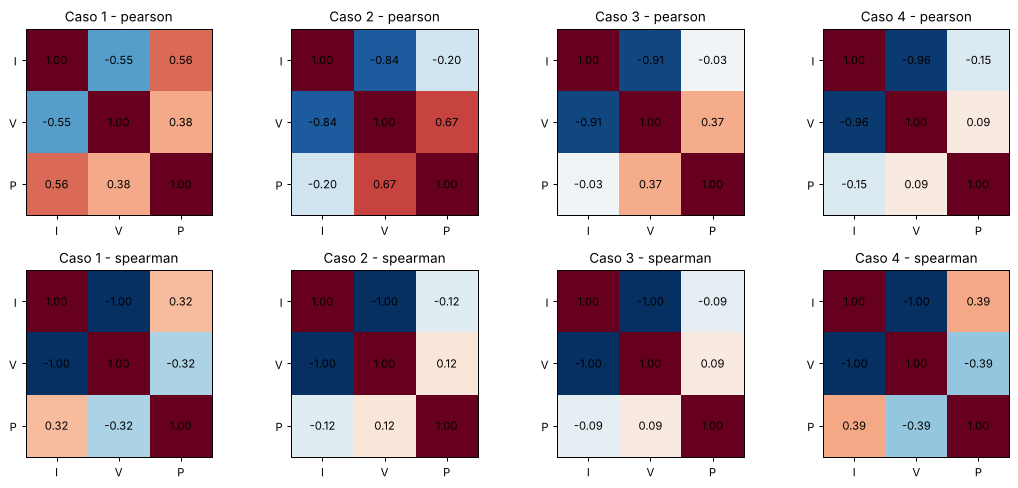

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5.5))
for c, i in enumerate(CASOS):
    for r, metodo in enumerate(["pearson", "spearman"]):
        m = datos[i][VARS].corr(method=metodo)
        axes[r, c].imshow(m, vmin=-1, vmax=1, cmap="RdBu_r")
        for a in range(3):
            for b in range(3):
                axes[r, c].text(b, a, f"{m.iloc[a, b]:.2f}", ha="center", va="center")
        axes[r, c].set_xticks(range(3))
        axes[r, c].set_xticklabels(["I", "V", "P"])
        axes[r, c].set_yticks(range(3))
        axes[r, c].set_yticklabels(["I", "V", "P"])
        axes[r, c].grid(False)
        axes[r, c].set_title(f"Caso {i} - {metodo}")
fig.tight_layout()
fig.savefig(OUT_DIR / "correlaciones.png", dpi=120, bbox_inches="tight")
plt.show()

Corriente y voltaje tienen una correlación de Spearman de -1 en todos los casos: siempre que el voltaje sube, la corriente baja. La correlación de Pearson es más baja (entre -0.55 y -0.96) porque la relación no es una línea recta.

La correlación de la potencia con el voltaje o la corriente es débil y cambia de un caso a otro. Esto no quiere decir que no estén relacionadas (la potencia es voltaje × corriente), sino que la relación sube y baja formando picos, y un coeficiente de correlación no captura ese tipo de relación. Por eso, para este problema, las curvas de la sección 8.1 describen mejor la relación entre variables.

### 8.3 P-V frente a P-I

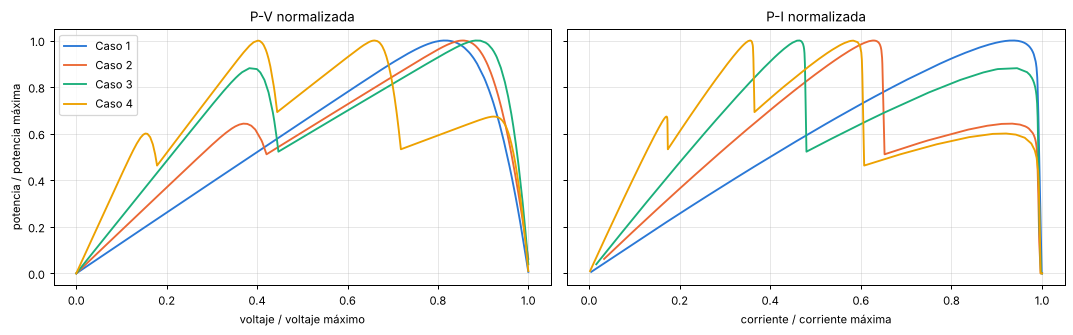

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for i, d in datos.items():
    p_norm = d["potencia"] / d["potencia"].max()
    axes[0].plot(d["voltaje"] / d["voltaje"].max(), p_norm, color=COLORES[i], label=f"Caso {i}")
    axes[1].plot(d["corriente"] / d["corriente"].max(), p_norm, color=COLORES[i])
axes[0].set(xlabel="voltaje / voltaje máximo", ylabel="potencia / potencia máxima", title="P-V normalizada")
axes[1].set(xlabel="corriente / corriente máxima", title="P-I normalizada")
axes[0].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "PV_vs_PI.png", dpi=120, bbox_inches="tight")
plt.show()

Para comparar los casos entre sí, cada curva se dividió por sus valores máximos. Las dos gráficas muestran los mismos picos, porque vienen de la misma curva I-V, pero se ven distintas. En P-I, los tramos donde la corriente casi no cambia (los escalones) aparecen como líneas casi verticales.

Las ventajas de usar referencias de corriente (P-Iref) frente a referencias de voltaje (P-Vref) descritas en la sección 5 tienen que ver con el comportamiento del controlador y del algoritmo. Se evaluarán en las fases de experimentación del proyecto.

## 9. Preprocesamiento

**9.1 Archivos duplicados.** Se descartan los archivos `caso_*.csv` porque contienen los mismos datos que `Caso*.csv` (sección 6.2).

**9.2 Valores faltantes.** No hay valores faltantes (sección 6.3), por lo que no se requiere imputación.

**9.3 Valores atípicos.** Se conservan. Los puntos marcados por la regla IQR son parte de la curva física (extremos y escalones), no errores. Eliminarlos cambiaría la forma de la curva que el algoritmo MPPT debe recorrer.

**9.4 Alta cardinalidad.** No aplica: la única variable categórica, `caso`, tiene 4 categorías.

**9.5 Selección de variables.** La potencia se puede calcular a partir del voltaje y la corriente, así que la información de cada punto está en esas dos variables. La potencia se mantiene porque es la variable que el algoritmo MPPT busca maximizar.

Finalmente, se guarda el conjunto limpio en un solo archivo.

In [11]:
df_all[VARS + ["caso"]].to_csv(OUT_DIR / "datos_limpios.csv", index=False)
print("Archivo guardado:", OUT_DIR / "datos_limpios.csv", "| filas:", len(df_all))

Archivo guardado: outputs/datos_limpios.csv | filas: 1392


## 10. Conclusiones del EDA

- **Valores faltantes:** no hay valores faltantes ni duplicados.
- **Estadísticas resumidas:** la potencia máxima va de 46.7 W (Caso 3) a 201.0 W (Caso 1); el voltaje máximo es similar en los cuatro casos (35-37 V) y la corriente máxima depende de la irradiancia.
- **Valores atípicos:** los que detecta la regla IQR son puntos válidos de la curva y se conservan.
- **Cardinalidad:** la única variable categórica (`caso`) tiene 4 categorías.
- **Distribuciones sesgadas:** sí, pero se deben a cómo el simulador reparte los puntos sobre la curva; no se aplicaron transformaciones.
- **Tendencias temporales:** no aplica, los datos no tienen dimensión de tiempo.
- **Correlación:** corriente y voltaje tienen una relación inversa (Spearman = -1). La potencia depende de ambas, pero con picos, por lo que la correlación lineal no la describe bien.
- **Distribución por categorías:** el Caso 1 (sin sombreado) tiene un pico; los Casos 2 y 3 tienen dos; el Caso 4 tiene cuatro, con los dos más altos casi iguales.
- **Desbalance de clases e imágenes:** no aplica; no hay variable objetivo de clasificación ni imágenes.

**Ideas principales para las siguientes etapas:**

1. El sombreado parcial genera varios picos en la curva P-V, lo que confirma que el problema requiere algoritmos de búsqueda global como el MSAPSO.
2. El Caso 4 es el más exigente porque sus dos picos más altos tienen casi la misma potencia en voltajes distintos.
3. Con solo cuatro curvas, los resultados describen estos escenarios específicos. Para generalizar se necesitarán los datos sintéticos descritos en la sección 2.

## 11. Referencias bibliográficas

- Clerc, M., & Kennedy, J. (2002). The particle swarm-explosion, stability, and convergence in a multidimensional complex space. *IEEE Transactions on Evolutionary Computation*.
- Esram, T., & Chapman, P. L. (2007). Comparison of photovoltaic array maximum power point tracking techniques. *IEEE Transactions on Energy Conversion*.
- Levant, A. (1993). Sliding order and sliding accuracy in sliding mode control. *International Journal of Control*.
- Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., & Müller, K.-R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality assurance methodology. *Machine Learning and Knowledge Extraction*. https://doi.org/10.3390/make3020020
- [Pendiente] Paper base: *Hybrid MPPT with Deterministic PSO and Super-Twisting: Minimum-Time Tracking under Complex Partial Shading*. Autores, año y estado de publicación por validar.